# Detect change points in AMOC-WHSST relation using a genetic algorithm

## Import packages and data

In [1]:
import numpy as np
import xarray as xr
import statsmodels.api as sm
from scipy.optimize import least_squares
import matplotlib.pyplot as plt 
import time
from random import choices

file_dir = '../../data/diagnosis/'
all_amoc_fname = 'CESM2_AMOC40_allexp_smooth_dump.txt' # the txt file that contains all AMOC points
all_whsst_fname = 'CESM2_WHI_allexp_smooth_dump.txt' # the txt file that contains all WHSST points

Data Length | Min | Max | Mean | STD  
 X:  39935 4.070046424865723 31.79815101623535 20.33390674751065 4.2904319008091045 
 Y:  39935 -11.309258442840534 -6.002378794199073 -7.695278806909482 0.9682737079371244
90% range of X:  [10.763696   25.81541576]


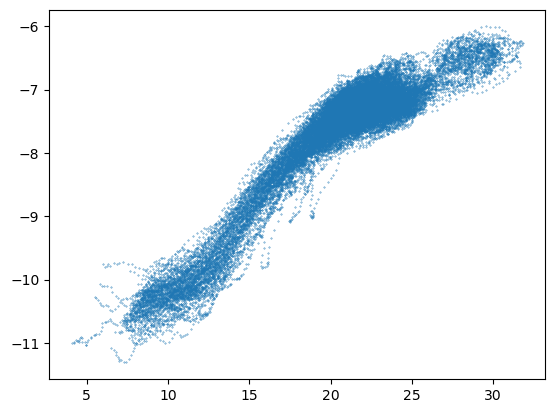

In [2]:
## Data input and preview
x = np.loadtxt(file_dir+all_amoc_fname)
y = np.loadtxt(file_dir+all_whsst_fname)

plt.scatter(x,y,s=0.1)
print('Data Length | Min | Max | Mean | STD ', '\n', 
      'X: ',len(x),x.min(),x.max(),x.mean(),x.std(),'\n',  # useful for generating initial guesses of change points
      'Y: ',len(y),y.min(),y.max(),y.mean(),y.std()) 
print('90% range of X: ', np.quantile(x, [0.05,0.95]))

## Genetic Algorithm Hyper-parameter Set-up & Sub-routines

In [5]:
N = 1000 # Number of individuals/populations (combinations of CPs)
maxG = 100 # Max Generations
elite_frac = 0.1 # Fraction of elite individuals that are passed directly to the next population
co_frac = 0.5 # # Fraction of crossovers 

elite_num = int(elite_frac*N) # Elite Count
co_num = int(co_frac*(N-elite_num)) # Crossover Count
mutation_num = N-elite_num-co_num # Mutation Count

# tolerance = 1e-10 # Tolerance
same_count = 10 # Stop the algorithm when the best individual of one generation stays the same for x generations 

In [6]:
# Calculate mean squared errors
def MSE(y,y_pre):
    return np.mean((y-y_pre)**2,axis=0)

# Define a function to calculate the predicted value of y, given sets of parameters 
def preY(x, params):
    # Input: 
    #        x: input x 
    #        params: MULTIPLE sets of parameters
    #
    # Output: predicted values of x, given multiple sets of parameters for the linear model with 1-4 break points

    N = len(params[0]) # number of individuals
    y_pre = np.zeros((len(x), N))

    # Two linear lines, 1 CP
    if (len(params)==4):
        a,b1,b2,xc = params
        # Calculate predicted y values for each individal set 
        for i in range(N):
            y_pre[:,i] = np.where(x<xc[i],
                                  a[i]+b1[i]*x, 
                                  a[i]+b1[i]*xc[i]+b2[i]*(x-xc[i]))
        return y_pre
    
    # Three linear lines, 2 CP
    elif (len(params)==6):
        a,b1,b2,b3 = params[:4,:]
        xc1,xc2 = np.sort(params[4:,:],axis=0) # make sure the change points are in ascending order 
        for i in range(N):
            # y values for 1st regime
            y_pre[:,i] = np.where(x<xc1[i], 
                                  a[i]+b1[i]*x,a[i]+b1[i]*xc1[i]+b2[i]*(x-xc1[i])) 
            
            # update y values for 2st regime
            y_pre[:,i] = np.where(x>=xc2[i], 
                                  a[i]+b1[i]*xc1[i]+b2[i]*(xc2[i]-xc1[i])+b3[i]*(x-xc2[i]),
                                  y_pre[:,i])
        return y_pre
    
    # Four linear lines, 3 CP
    elif (len(params)==8):
        a,b1,b2,b3,b4 = params[:5,:]
        xc1,xc2,xc3 = np.sort(params[5:,:],axis=0)
        for i in range(len(a)):
            y_pre[:,i] = np.where(x<xc1[i],
                                  a[i]+b1[i]*x,a[i]+b1[i]*xc1[i]+b2[i]*(x-xc1[i]))
            y_pre[:,i] = np.where((x>=xc2[i])&(x<xc3[i]),
                                  a[i]+b1[i]*xc1[i]+b2[i]*(xc2[i]-xc1[i])+b3[i]*(x-xc2[i]),
                                  y_pre[:,i])
            y_pre[:,i] = np.where((x>=xc3[i]),
                                  a[i]+b1[i]*xc1[i]+b2[i]*(xc2[i]-xc1[i])+b3[i]*(xc3[i]-xc2[i])+b4[i]*(x-xc3[i]),
                                  y_pre[:,i])
        return y_pre
    
    # Five linear lines, 4 CP
    elif (len(params)==10):
        a,b1,b2,b3,b4,b5 = params[:6,:]
        xc1,xc2,xc3,xc4 = np.sort(params[6:,:],axis=0)
        for i in range(len(a)):
            y_pre[:,i] = np.where(x<xc1[i],a[i]+b1[i]*x,
                                  a[i]+b1[i]*xc1[i]+b2[i]*(x-xc1[i]))
            y_pre[:,i] = np.where((x>=xc2[i])&(x<xc3[i]),a[i]+b1[i]*xc1[i]+b2[i]*(xc2[i]-xc1[i])+b3[i]*(x-xc2[i]),
                                  y_pre[:,i])
            y_pre[:,i] = np.where((x>=xc3[i])&(x<xc4[i]),
                                  a[i]+b1[i]*xc1[i]+b2[i]*(xc2[i]-xc1[i])+b3[i]*(xc3[i]-xc2[i])+b4[i]*(x-xc3[i]),
                                  y_pre[:,i])
            y_pre[:,i] = np.where((x>=xc4[i]),
                                  a[i]+b1[i]*xc1[i]+b2[i]*(xc2[i]-xc1[i])+b3[i]*(xc3[i]-xc2[i])+b4[i]*(xc4[i]-xc3[i])+b5[i]*(x-xc4[i]),
                                  y_pre[:,i])
        return y_pre        

    else: 
        print('Wrong number of parameters!')
        
        
# Define a linear fit model with a set of known fitting parameters
def LinearFit(x, params):
    # Input: 
    #        x: input x
    #        params: ONE set of parameters, like [a,b1,b2,cp1]
    #
    # Output: a function of x (e.g., F_x)
    
    # Two linear lines, 1 CP  
    if (len(params)==4):
        a,b1,b2,xc = params
        F_x = np.where(x<xc, a+b1*x, 
                       a+b1*xc+b2*(x-xc))
        return F_x
    
    # Three linear lines, 2 CP
    elif (len(params)==6):
        a,b1,b2,b3 = params[:4]
        xc1,xc2 = np.sort(params[4:]) # make sure the change points are in ascending order
        F_x1 = np.where(x<xc1, a+b1*x, 
                         a+b1*xc1+b2*(x-xc1))
        F_x2 = np.where(x>=xc2, a+b1*xc1+b2*(xc2-xc1)+b3*(x-xc2), 
                       F_x1)
        return F_x2
    
    # Four linear lines, 3 CP
    elif (len(params)==8):
        a,b1,b2,b3,b4 = params[:5] 
        xc1,xc2,xc3 = np.sort(params[5:]) 
        F_x1 = np.where(x<xc1,a+b1*x,
                         a+b1*xc1+b2*(x-xc1))
        F_x2 = np.where((x>=xc2)&(x<xc3), 
                         a+b1*xc1+b2*(xc2-xc1)+b3*(x-xc2),
                         F_x1)
        F_x3 = np.where(x>=xc3,
                       a+b1*xc1+b2*(xc2-xc1)+b3*(xc3-xc2)+b4*(x-xc3),
                       F_x2) 
        return F_x3
    
    # Five linear lines, 4 CP
    elif (len(params)==10):
        a,b1,b2,b3,b4,b5 = params[:6]
        xc1,xc2,xc3,xc4 = np.sort(params[6:]) 
        F_x1 = np.where(x<xc1, a+b1*x, 
                         a+b1*xc1+b2*(x-xc1))
        F_x2 = np.where((x>=xc2)&(x<xc3), 
                         a+b1*xc1+b2*(xc2-xc1)+b3*(x-xc2),
                         F_x1)
        F_x3 = np.where((x>=xc3)&(x<xc4),
                         a+b1*xc1+b2*(xc2-xc1)+b3*(xc3-xc2)+b4*(x-xc3),
                         F_x2)
        F_x4 = np.where(x>=xc4, a+b1*xc1+b2*(xc2-xc1)+b3*(xc3-xc2)+b4*(xc4-xc3)+b5*(x-xc4), 
                       F_x3) 
        return F_x4
    
    else:
        print('Something wrong!')


# Define the function to find the OLS parameters for each regime, given an unknown number (<5) of change points 
def find_ols_params(x, y, cps):
    # x, y: input x and y
    # cps: Change Points [index_of_CP,index_of_individual]
    # return the estimated parameters (first regression coefficient, then change points)
    
    N = cps.shape[1]  # number of individuals (N=1000)
    nc = cps.shape[0] # number of change points 
    
    # Create an array to store estimated parameters
    params = np.zeros((nc*2+2,N))
    
    # For each individual set of change points, find the best fit in the first regime
    for i in range(N):
        if (nc==1):
            # 1) Split the input data, given the change points
            xc = cps[0,i]
            x_temp1 = x[np.where(x<=xc)[0]]
            y_temp1 = y[np.where(x<=xc)[0]]
            
            # 2) Estimate the fitting parameter for this regime 
            mod=sm.OLS(y_temp1,sm.add_constant(x_temp1)).fit()
            b0,b1 = mod.params[:]
            y_xc = xc*b1+b0 
        
            # 3) Similarly, find the best fit in the second regime
            # The best fit line must go through the point (xc,y_xc) 
            x_temp2 = x[np.where(x>xc)[0]]-xc   # so that y_pre = k*x
            y_temp2 = y[np.where(x>xc)[0]]-y_xc # so that y_pre = k*x
            
            # 4) To Estimate the sum of squared error, given y_pre = k*x, used for optimizting unknown parameter k 
            def SSE(k,x=x_temp2,y=y_temp2):
                # k: unknown value of the slope 
                # x, y: known x and y (np.array)
                return np.sum((k*x-y)**2)
            b2 = least_squares(SSE, x0=np.array([0.2])).x[0]  # here, x0 is the initial guess for k
            params[:,i] = np.array([b0,b1,b2,xc])
            
        elif(nc==2):
            # Use OLS fitting to find the best fit in the second (middle) regime
            xc1,xc2 = np.sort(cps[:,i])
            x_temp = x[np.where((x>xc1)&(x<=xc2))[0]]
            y_temp = y[np.where((x>xc1)&(x<=xc2))[0]]
            mod=sm.OLS(y_temp,sm.add_constant(x_temp)).fit()
            b2 = mod.params[1] # slope of the second regime 
            y_xc1 = xc1*b2+mod.params[0] 
            y_xc2 = xc2*b2+mod.params[0] 
            
            x_temp1 = x[np.where(x<=xc1)[0]]-xc1
            y_temp1 = y[np.where(x<=xc1)[0]]-y_xc1
            def SSE(k,x=x_temp1,y=y_temp1):
                return np.sum((k*x-y)**2)
            b1 = least_squares(SSE,x0=np.array([0.2])).x[0]
            b0 = y_xc1-b1*xc1
            
            x_temp2 = x[np.where(x>xc2)[0]]-xc2
            y_temp2 = y[np.where(x>xc2)[0]]-y_xc2
            def SSE(k,x=x_temp2,y=y_temp2):
                return np.sum((k*x-y)**2)
            b3 = least_squares(SSE,x0=np.array([0.2])).x[0]
                        
            params[:,i] = np.array([b0,b1,b2,b3,xc1,xc2])
            
        elif(nc==3):
            xc1,xc2,xc3 = np.sort(cps[:,i])
            x_temp = x[np.where((x>xc1)&(x<=xc2))[0]]
            y_temp = y[np.where((x>xc1)&(x<=xc2))[0]]
            mod=sm.OLS(y_temp,sm.add_constant(x_temp)).fit()
            b2 = mod.params[1] # slope of the second regime 
            y_xc1 = xc1*b2+mod.params[0] 
            y_xc2 = xc2*b2+mod.params[0] 
            
            x_temp1 = x[np.where(x<=xc1)[0]]-xc1
            y_temp1 = y[np.where(x<=xc1)[0]]-y_xc1
            def SSE(k,x=x_temp1,y=y_temp1):
                return np.sum((k*x-y)**2)
            b1 = least_squares(SSE,x0=np.array([0.2])).x[0]
            b0 = y_xc1-b1*xc1
            
            x_temp2 = x[np.where((x>xc2)&(x<=xc3))[0]]-xc2
            y_temp2 = y[np.where((x>xc2)&(x<=xc3))[0]]-y_xc2
            def SSE(k,x=x_temp2,y=y_temp2):
                return np.sum((k*x-y)**2)
            b3 = least_squares(SSE,x0=np.array([0.2])).x[0]
            y_xc3 = (xc3-xc2)*b3+y_xc2
            
            x_temp3 = x[np.where(x>xc3)[0]]-xc3
            y_temp3 = y[np.where(x>xc3)[0]]-y_xc3
            def SSE(k,x=x_temp3,y=y_temp3):
                return np.sum((k*x-y)**2)
            b4 = least_squares(SSE,x0=np.array([0.2])).x[0]
            
            params[:,i] = np.array([b0,b1,b2,b3,b4,xc1,xc2,xc3])
       
        elif(nc==4):
            xc1,xc2,xc3,xc4 = np.sort(cps[:,i])
            x_temp = x[np.where((x>xc1)&(x<=xc2))[0]]
            y_temp = y[np.where((x>xc1)&(x<=xc2))[0]]
            mod=sm.OLS(y_temp,sm.add_constant(x_temp)).fit()
            b2 = mod.params[1] # slope of the second regime 
            y_xc1 = xc1*b2+mod.params[0] 
            y_xc2 = xc2*b2+mod.params[0] 
            
            x_temp1 = x[np.where(x<=xc1)[0]]-xc1
            y_temp1 = y[np.where(x<=xc1)[0]]-y_xc1
            def SSE(k,x=x_temp1,y=y_temp1):
                return np.sum((k*x-y)**2)
            b1 = least_squares(SSE,x0=np.array([0.2])).x[0]
            b0 = y_xc1-b1*xc1
            
            x_temp2 = x[np.where((x>xc2)&(x<=xc3))[0]]-xc2
            y_temp2 = y[np.where((x>xc2)&(x<=xc3))[0]]-y_xc2
            def SSE(k,x=x_temp2,y=y_temp2):
                return np.sum((k*x-y)**2)
            b3 = least_squares(SSE,x0=np.array([0.2])).x[0]
            y_xc3 = (xc3-xc2)*b3+y_xc2

            x_temp3 = x[np.where((x>xc3)&(x<=xc4))[0]]-xc3
            y_temp3 = y[np.where((x>xc3)&(x<=xc4))[0]]-y_xc3
            def SSE(k,x=x_temp3,y=y_temp3):
                return np.sum((k*x-y)**2)
            b4 = least_squares(SSE,x0=np.array([0.2])).x[0]
            y_xc4 = (xc4-xc3)*b4+y_xc3
            
            x_temp4 = x[np.where(x>xc4)[0]]-xc4
            y_temp4 = y[np.where(x>xc4)[0]]-y_xc4
            def SSE(k,x=x_temp4,y=y_temp4):
                return np.sum((k*x-y)**2)
            b5 = least_squares(SSE,x0=np.array([0.2])).x[0]
            
            params[:,i] = np.array([b0,b1,b2,b3,b4,b5,xc1,xc2,xc3,xc4])
        else:
            params[:,i] = np.nan
    
    #print(params[-1,:]) 
    return params

# Define the function to find the OLS parameters for each regime, given two change points 
def find_ols_params_2cp(x,y,cps):
    # x, y: input x and y
    # cps: Change Points [index_of_CP,index_of_individual]
    
    N = cps.shape[1]  # number of individuals (N=1000)
    nc = cps.shape[0] # number of change points 
    
    # Create an array to store estimated parameters
    params = np.zeros((nc*2+2,N))
    
    # For each individual set of change points, find the best fit in the first regime
    for i in range(N):
        # Use OLS fitting to find the best fit in the second (middle) regime
        xc1,xc2 = np.sort(cps[:,i])
        x_temp = x[np.where((x>xc1)&(x<=xc2))[0]]
        y_temp = y[np.where((x>xc1)&(x<=xc2))[0]]
        mod=sm.OLS(y_temp,sm.add_constant(x_temp)).fit()
        b2 = mod.params[1] # slope of the second regime 
        y_xc1 = xc1*b2+mod.params[0] 
        y_xc2 = xc2*b2+mod.params[0] 
            
        x_temp1 = x[np.where(x<=xc1)[0]]-xc1
        y_temp1 = y[np.where(x<=xc1)[0]]-y_xc1
        def SSE(k,x=x_temp1,y=y_temp1):
            return np.sum((k*x-y)**2)
        b1 = least_squares(SSE,x0=np.array([0.2])).x[0]
        b0 = y_xc1-b1*xc1
            
        x_temp2 = x[np.where(x>xc2)[0]]-xc2
        y_temp2 = y[np.where(x>xc2)[0]]-y_xc2
        def SSE(k,x=x_temp2,y=y_temp2):
            return np.sum((k*x-y)**2)
        b3 = least_squares(SSE,x0=np.array([0.2])).x[0]
                        
        params[:,i] = np.array([b0,b1,b2,b3,xc1,xc2])
    return params

## Main routine to find the CP combination that optimizes the fitting model using a genetic algorithm 

In [7]:
def gene(x,y, cps0, 
         N = N, 
         maxG = maxG,
         elite_num = elite_num,
         co_num = co_num, 
         mutation_num = mutation_num,
         same_count = same_count):
    
    ################ Input ##############
    # x, y: input x and y
    # cps0: the initial guess of change points 
    # N: Number of individuals
    # elite_num: Number of elite individuals that are passed directly to the next population
    # co_num: Number of crossover children 
    # mutation_num: Number of children with mutation 
    # same_count: Condition for ending the routine; 
    #             when the best individual of one generation stays the same for this number of generations 
    # return:
    #        A list of the "fittest" parameters at each generation (the last element is the final estimate)
    #####################################
    
    ## 1. Set up 
    nc = cps0.shape[0] # number of change points  
    nparam = nc*2+2 # number of total parameters
    
    # Create a array to storage the performance of the "best" individual at each generation 
    # The "best" means that the set of parameters minimizes the MSE of the fitting 
    mse_best = np.zeros(maxG)
    mse_best[:] = np.nan # initialization
    
    # Create a array to store the "best" individual at each generation 
    para_best = []
    
    for i in range(maxG):
        print(i)
        ## 2.1 Evaluate the performance of the current population
        # predicted values using the initial combination of the four parameters
        
        param0 = find_ols_params(x,y,cps0) # Can be changed to --> find_ols_params_2cp(x,y,cps0)
        y_pre0 = preY(x,param0)

        # performance score, estimated by mean squared error
        Y = np.asarray(np.asmatrix(y).T*np.asmatrix(np.ones(N))) 
        mse0 = MSE(Y,y_pre0)
        
        # reorder the individuals by its MES
        param0_reorder = param0[:,np.argsort(mse0)] # [best, ..., worst]
        
        ## 2.2 Create the next generation 
        # 2.2.1 Select elite children, that is, the elite_num sets of parameters giving the lowest MSE
        param0[:,:elite_num] = param0_reorder[:,:elite_num]
        para_best.append(param0_reorder[:,0])
        mse_best[i] = np.min(mse0)
        #print(mse_best[i])
        
        # 2.2.2 Create crossover children        
        # 2.2.2.1 Select two parents, "mom" and "dad"
        weights = np.arange(N,0,-1)/np.sum(np.arange(1,N+1))
        mom_idx = choices(population=np.arange(0,N,1), weights=weights,k=int(co_num/2))
        dad_idx = choices(population=np.arange(0,N,1), weights=weights,k=int(co_num/2))
        
        # 2.2.2.2 Select crossover point (if zero, means keep all elements from ther other parent)
        co_pt = np.random.randint(low=0, high=nparam,size=int(co_num/2))
        
        # 2.2.2.3 Combine genes to create children 
        # for each pair of parents 
        for k in range(int(co_num/2)):
            # first child
            param0[:,elite_num+2*k]=np.append(param0_reorder[:co_pt[k],mom_idx[k]],param0_reorder[co_pt[k]:,dad_idx[k]])
            # second child 
            param0[:,elite_num+2*k+1]=np.append(param0_reorder[:co_pt[k],dad_idx[k]],param0_reorder[co_pt[k]:,mom_idx[k]])

        # 2.2.3 Create mutation children 
        # select individuals to perturb 
        mutation_index = np.random.randint(low=0, high=N-1,size=mutation_num)
        # adds a random vector (0.05) from a normal distribution
        param0[-nc:,-mutation_num:] = param0_reorder[-nc:,mutation_index] + np.ones((nc,mutation_num))/20
        
        cps0 = param0[nparam-nc:,:]
        
        ## 3. Stop condition 
        if (i>same_count):
            if (mse_best[i-same_count:i+1].min()==mse_best[i-same_count:i+1].max()):
                return para_best
            
    return para_best

## Subsampling to estimate uncertainty range


In [8]:
# load data
file_dir = '../../data/CESM2_clean_dataset/'
amoc = {}
whi = {}
exps = ['LE','SF-GHG','SF-AAER','SF-GHG','SF-AAER','SF-xAER','SF-EE','SF-BMB']
for exp in exps: 
    print(exp)
    f = xr.open_mfdataset(file_dir+'AMOCI/CESM2-'+exp+'_AMOC40_ts_*.nc',combine='by_coords')
    amoc[exp] = f[list(f.data_vars)[0]].load()
    f = xr.open_dataset(file_dir+'SSTand/CESM2-'+exp+'_WHI_full.nc')
    whi[exp] = f[list(f.data_vars)[0]]

LE
SF-GHG
SF-AAER
SF-GHG
SF-AAER
SF-xAER
SF-EE
SF-BMB


[58 97  3]
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
0 3 [-10.88566577   0.05169625   0.3595702    0.09697533  11.96
  19.82      ]


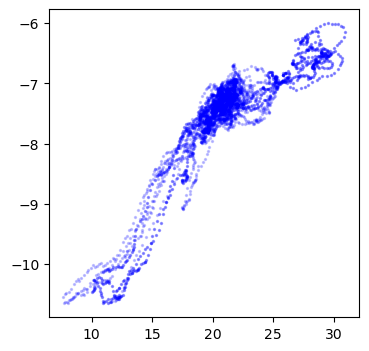

[59 58  3]
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
1 3 [-11.14945876   0.07881026   0.34448696   0.09662802  11.92
  20.1       ]


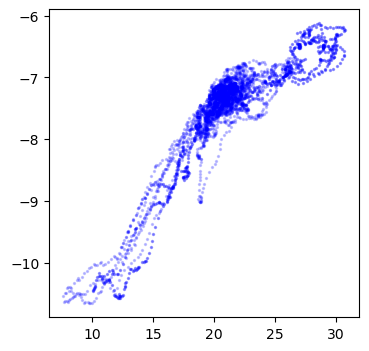

[97  8 82]
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
2 3 [-1.05248694e+01  1.35041817e-02  3.10614478e-01  9.68619007e-02
  1.04100000e+01  2.00000000e+01]


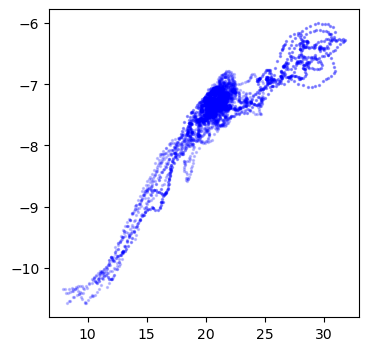

[60 11 61]
0
1
2
3
4
5
6
7
8
9
10
11
12
13
3 3 [-10.87001867   0.05115601   0.36741549   0.10157926  12.05
  19.64      ]


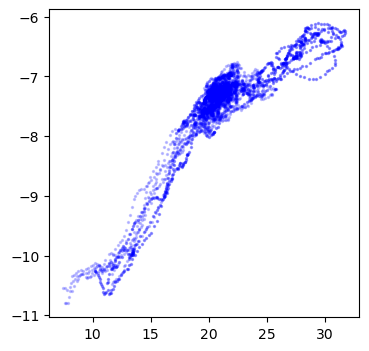

[60 39  3]
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
4 3 [-11.75681428   0.14101614   0.33358541   0.1033959   11.92
  19.75      ]


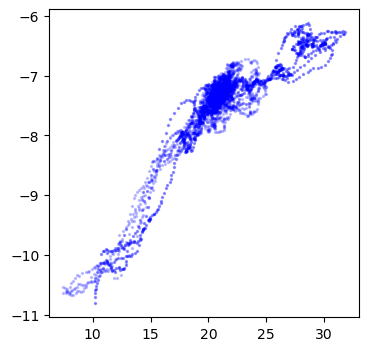

[ 1 24 50]
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
5 3 [-11.34359092   0.10430788   0.3459613    0.09304241  12.25
  19.92      ]


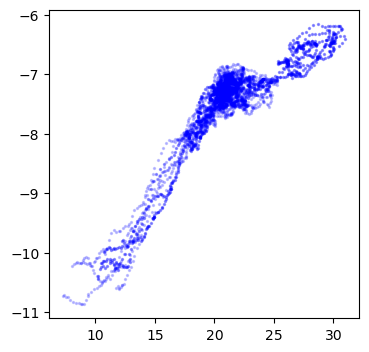

[42 18 40]
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
6 3 [-11.09646982   0.09827047   0.33967285   0.09733927  13.15
  20.32      ]


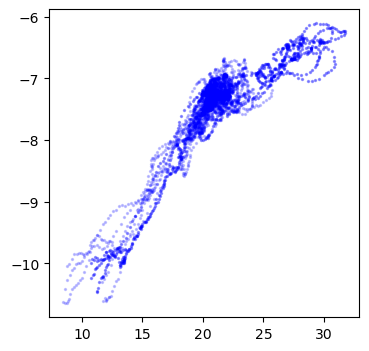

[12 83 38]
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
7 3 [-10.60809782   0.03217547   0.35054775   0.09478283  11.84
  19.81      ]


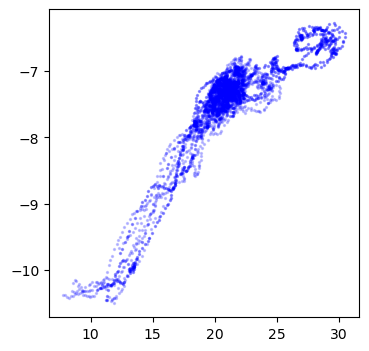

[30 12  0]
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
8 3 [-10.94801146   0.07665796   0.32057024   0.10023072  11.84
  20.        ]


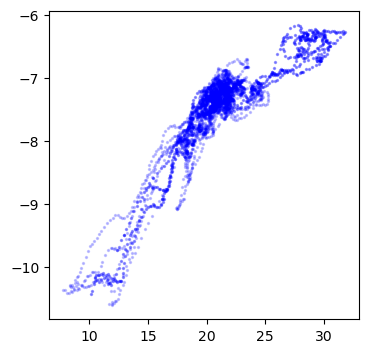

[38 37 26]
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
9 3 [-10.9062364    0.0726532    0.3636497    0.10092952  12.6
  19.48      ]


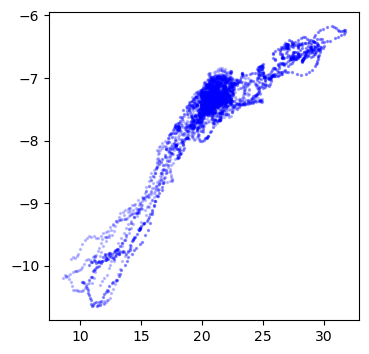

[29 16 34]
0
1
2
3
4
5
6
7
8
9


In [ ]:
def smooth(var,twindow=15):
    temp = var.rolling(year=twindow,center=True).mean('year')
    return temp.where(temp.isnull()==False,drop=True)

def dump_data(amoc, whi, exps=exps):
    amoc_dump = []
    whi_dump = []
    for e in exps:
        X = smooth(amoc[e]).values.flatten()
        Y = smooth(whi[e]).values.flatten()
        amoc_dump.extend(X.tolist())
        whi_dump.extend(Y.tolist())
    return np.array(amoc_dump), np.array(whi_dump)
    
def random_subset_runs(amoc, whi, subset_n, exps2subset): 
    amoc_sub = amoc.copy()
    whi_sub = whi.copy()
    for e in exps2subset:
        sel_rlzn = np.random.choice(len(amoc[e]), size=subset_n, replace=False)
        amoc_sub[e] = amoc[e].isel(rlzn=sel_rlzn)
        whi_sub[e] = whi[e].isel(rlzn=sel_rlzn)
        if (e=='LE'):
            print(sel_rlzn)
    return amoc_sub, whi_sub

start_time = time.time()
test_param_bootstrap = []

xc = 17 # critical value to set up the initial guesses of the two change points
N_subsampling_times = 143
constant_n = 3 # the minimum number of historical simulations used for CMIP6 models
random_subset_n = np.zeros(100,dtype=int) +  constant_n#np.random.randint(low=10, high=67, size=100)
with open("../../data/diagnosis/detection_subsampling_"+str(constant_n)+"runs_params_100times.txt", "a") as f:
    for i in range(N_subsampling_times): 
        subset_n = random_subset_n[i] #random_subset_n[i]
        if (subset_n>=10)&(subset_n<15):
            exps2subset = ['LE','SF-AAER','SF-GHG','SF-EE','SF-BMB']
        elif (subset_n>=15)&(subset_n<20):
            exps2subset = ['LE','SF-AAER']
        elif (subset_n>=20):
            exps2subset = ['LE']
        else:
            exps2subset=['LE','SF-AAER','SF-GHG','SF-EE','SF-BMB','SF-xAER']
            
        amoc_sub, whi_sub = random_subset_runs(amoc, whi, subset_n = subset_n, exps2subset=exps2subset)
        amoc_dump, whi_dump = dump_data(amoc_sub, whi_sub)
        x_min, x_max = amoc_dump.min(), amoc_dump.max()
        cps0 = np.asarray([np.random.randint(low=np.ceil(x_min)*100, high=xc*100, size=N)/100,
                           np.random.randint(low=xc*100, high=np.floor(x_max)*100, size=N)/100])
        test_params = gene(amoc_dump, whi_dump, cps0)[-1]
        print(i, subset_n, test_params)
        array2write = np.array(test_params)
        np.savetxt(f, array2write.reshape(1, -1), fmt="%.4f")
        
        fig = plt.subplots(1,1, figsize=(4,4))
        plt.scatter(amoc_dump, whi_dump,s=2,alpha=0.2,c='b')
        plt.show()
    
end_time = time.time()
elapsed_time = (end_time - start_time)
print(f"Elapsed time: {elapsed_time:.4f} seconds")

(1000, 6)
14.66 9.94
20.6 17.51


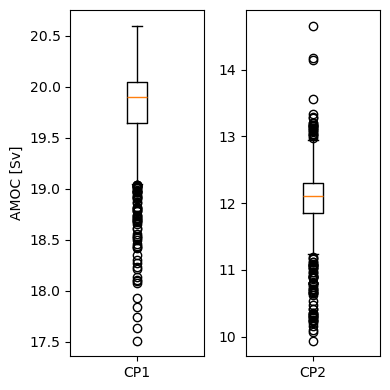

In [21]:
constant_n = 3
all_params = np.loadtxt("../../data/diagnosis/detection_subsampling_"+str(constant_n)+"runs_params_100times.txt")
print(all_params.shape)
print(all_params[:,-2].max(),all_params[:,-2].min())
print(all_params[:,-1].max(),all_params[:,-1].min())

fig, axs = plt.subplots(1,2, figsize=(4,4))
axs[1].boxplot(all_params[:,-2])
axs[0].boxplot(all_params[:,-1])
plt.tight_layout()
axs[0].set_xticks([1],['CP1'])
axs[1].set_xticks([1],['CP2'])
axs[0].set_ylabel('AMOC [Sv]')
plt.tight_layout()
plt.savefig('../../output/figures/Supplementary_ResampingEnsembleCP_boxplots.png',dpi=500)
plt.show()

## Compare different fitting models

In [ ]:
xin = np.arange(2.5,34.1,0.1) # psuedo input data 
mse = {} # dictionary to save mean square errors of derived models
y_fit = {} # dictionary to save fitted y values

### 1) Linar + 0 CP

In [ ]:
mod=sm.OLS(y,sm.add_constant(x)).fit()

fig, ax = plt.subplots(1,1)
plt.scatter(x,y,s=0.1)
plt.plot(xin,xin*mod.params[1]+mod.params[0],c='k',lw=1)
plt.show()

mse['OneLinear'] = MSE(y,x*mod.params[1]+mod.params[0])
print("MSE:", mse['OneLinear'])
y_fit['OneLinear'] = x*mod.params[1]+mod.params[0]
mod.summary()

### 2) Logarithmic fit

In [ ]:
mod_log = sm.OLS(y,sm.add_constant(np.log(x))).fit()

fig, ax = plt.subplots(1,1)
plt.scatter(x,y,s=0.1)
plt.plot(xin,np.log(xin)*mod_log.params[1]+mod_log.params[0],c='k',lw=1)
plt.show()

mse['Log'] = MSE(y,np.log(x)*mod_log.params[1]+mod_log.params[0])
y_fit['Log'] = np.log(x)*mod_log.params[1]+mod_log.params[0]
print("MSE:", mse['Log'])
mod_log.summary()

### 3) Linear + 1CP

In [ ]:
start_time = time.time()
np.random.seed(3) # generate the same random numbers every time we run the code

# initial change points [e.g., 12.12, 21.35, 16.84, ...]
cps0 = np.asarray([np.random.randint(low=1070, high=2580, size=N)/100])

temp1 = gene(x, y, cps0)[:]
best1 = temp1[-1]
print(best1)
mse['TwoLinear_N='+str(N)+'_EliteFrac='+str(elite_frac)+'_CrossOverFrac='+str(co_frac)] = MSE(y,LinearFit(x,best1))
print(mse['TwoLinear_N='+str(N)+'_EliteFrac='+str(elite_frac)+'_CrossOverFrac='+str(co_frac)])

y_fit['TwoLinear'] = LinearFit(x,best1)
plt.scatter(x,y,s=0.1)
plt.grid()
plt.plot(xin,LinearFit(xin,best1),lw=2,c='k')

end_time = time.time()
elapsed_time = (end_time - start_time)
print(f"Elapsed time: {elapsed_time:.4f} seconds")

### 4) Linear + 2CP

In [ ]:
start_time = time.time()
np.random.seed(3)

icut = 17
cps0 = np.asarray([np.random.randint(low=500, high=icut*100,size=N)/100,
                   np.random.randint(low=icut*100, high=3000,size=N)/100])
temp2 = gene(x,y,cps0)[:]
best2 = temp2[-1]
test_params = best2
test_mse = MSE(y,LinearFit(x,best2))
print(best2)

plt.scatter(x,y,s=0.1)
plt.grid()
plt.plot(xin, LinearFit(xin,best2), lw=2, c='k')
plt.axvline(x=best2[-2],lw=0.5,c='k')
plt.axvline(x=best2[-1],lw=0.5,c='k')

end_time = time.time()
elapsed_time = (end_time - start_time)
print(f"Elapsed time: {elapsed_time:.4f} seconds")

#### Test the sensitivity of CP detection to initial guess

In [ ]:
start_time = time.time()
np.random.seed(3)
cut_off_x = np.arange(12, 25, 1)

test_params = {}
test_mse = {}
for icut in cut_off_x:
    cps0 = np.asarray([np.random.randint(low=500, high=icut*100,size=N)/100,
                       np.random.randint(low=icut*100, high=3000,size=N)/100])
    temp2 = gene(x,y,cps0)[:]
    best2 = temp2[-1]
    test_params[str(icut)] = best2
    test_mse[str(icut)] = MSE(y,LinearFit(x,best2))
    print(best2)

end_time = time.time()
elapsed_time = (end_time - start_time)
print(f"Elapsed time: {elapsed_time:.4f} seconds")

In [ ]:
fig, axs = plt.subplots(3,1,figsize=(4,6),sharex=True)
for icut in cut_off_x[:-5]:
    axs[0].scatter(icut, test_params[str(icut)][-1], c='blue')
    axs[1].scatter(icut, test_params[str(icut)][-2], c='green')
    axs[2].scatter(icut, round(test_mse[str(icut)],4), c='k')
    
axs[0].set_ylabel('CP1 [Sv]')
axs[1].set_ylabel('CP2 [Sv]')
axs[2].set_ylabel('MSE')
axs[2].set_xlabel('Xc [Sv]')
for ax in axs:
    ax.grid(lw=0.1,c='grey')
plt.show()

best2 = test_params[str(17)]
y_fit['ThreeLinear'] = LinearFit(x, best2)
mse['ThreeLinear_N='+str(N)+'_EliteFrac='+str(elite_frac)+'_CrossOverFrac='+str(co_frac)] = MSE(y,y_fit['ThreeLinear'])
print(best2)

### 5) Linear + 3 CP

In [ ]:
start_time = time.time()
np.random.seed(1)

# Initial guess 
cps0 = np.asarray([np.random.randint(low=500, high=1300,size=N)/100,
                  np.random.randint(low=1900, high=2100,size=N)/100,
                  np.random.randint(low=2110, high=3000,size=N)/100])
temp3 = gene(x,y,cps0)[:]
best3 = temp3[-1]
print(best3)

y_fit['FourLinear'] = LinearFit(x,best3)
mse['FourLinear_N='+str(N)+'_EliteFrac='+str(elite_frac)+'_CrossOverFrac='+str(co_frac)] = MSE(y,y_fit['FourLinear'])
plt.scatter(x,y,s=0.1)
plt.plot(xin,LinearFit(xin,best3),lw=2,c='k')
plt.axvline(x=best3[-3],lw=0.5,c='k')
plt.axvline(x=best3[-2],lw=0.5,c='k')
plt.axvline(x=best3[-1],lw=0.5,c='k')

end_time = time.time()
elapsed_time = (end_time - start_time)
print(f"Elapsed time: {elapsed_time:.4f} seconds")

### 6) Linear + 4 CP

In [ ]:
start_time = time.time()
np.random.seed(1)
N=1000
cps0 = np.asarray([np.random.randint(low=500, high=1000,size=N)/100,
                   np.random.randint(low=1000, high=1300,size=N)/100,
                   np.random.randint(low=1900, high=2100,size=N)/100,
                   np.random.randint(low=2101, high=3000,size=N)/100])

temp4 = gene(x,y,cps0)[:]
best4 = temp4[-1]
print(best4)
mse['FiveLinear_N='+str(N)+'_EliteFrac='+str(elite_frac)+'_CrossOverFrac='+str(co_frac)] = MSE(y,LinearFit(x,best3))
print(mse['FiveLinear_N='+str(N)+'_EliteFrac='+str(elite_frac)+'_CrossOverFrac='+str(co_frac)])

y_fit['FiveLinear'] = LinearFit(x,best4)
plt.scatter(x,y,s=0.1)
plt.plot(xin,LinearFit(xin,best4),lw=2,c='k')
plt.axvline(x=best4[-4],lw=0.5,c='k')
plt.axvline(x=best4[-3],lw=0.5,c='k')
plt.axvline(x=best4[-2],lw=0.5,c='k')
plt.axvline(x=best4[-1],lw=0.5,c='k')

end_time = time.time()
elapsed_time = (end_time - start_time)
print(f"Elapsed time: {elapsed_time:.4f} seconds")

## Model Selection 

In [ ]:
def GL(y,y_pre,p):
    # y: observed y values
    # y_pre: predicted y values
    # p: number of parameters
    # return: the Gaussian likelihood [-N/2*(ln(2*pi)+ln(rss)+1)]
    N=len(y)
    rss = ((y-y_pre)**2).sum()/N # residue squared sum
    term1 = np.log10(2*np.pi)
    term2 = np.log10(rss)
    likelihood = -0.5*N*(term1+term2+1)
    #print(rss, term1, term2, likelihood)
    return likelihood

N_data = len(x)
p = {}
p['OneLinear'] = 2
p['Log'] = 2
p['TwoLinear'] = 4
p['ThreeLinear'] = 6
p['FourLinear'] = 8
#p['FiveLinear'] = 10

BIC = {} # Bayesian Information Criteria
for key in ['OneLinear','Log','TwoLinear','ThreeLinear','FourLinear']:
    BIC[key] = -2*(GL(y,y_fit[key],p[key]))+p[key]*np.log10(N_data)

In [ ]:
fig,axs = plt.subplots(1,2,figsize=(9,4)) 
plt.subplots_adjust(top=0.9,bottom=0.1,left=0.1,right=0.95,wspace=0.3)

axs[0].set_title('a',loc='left',fontdict={'weight': 'bold', 'size': 14})
axs[0].set_title('Fitting btw AMOC & WHI')
axs[0].scatter(x,y,s=0.1,c='silver',edgecolor=None)

axs[0].plot(xin,xin*mod.params[1]+mod.params[0],lw=2,c='cyan',label='Linear0')
axs[0].plot(xin,np.log(xin)*mod_log.params[1]+mod_log.params[0],lw=2,c='teal',label='Log')
axs[0].plot(xin,LinearFit(xin,best1),lw=2,c='dodgerblue',label='Linear1')
axs[0].axvline(x=best1[-1],lw=0.5,linestyle='--',c='dodgerblue')

axs[0].plot(xin,LinearFit(xin,best2),lw=2,c='navy',label='Linear2')
axs[0].axvline(x=best2[-2],lw=0.5,linestyle='--',c='navy')
axs[0].axvline(x=best2[-1],lw=0.5,linestyle='--',c='navy')

axs[0].plot(xin,LinearFit(xin,best3),lw=2,c='violet',label='Linear3')
axs[0].axvline(x=best3[-2],lw=0.5,linestyle='--',c='violet')
axs[0].axvline(x=best3[-3],lw=0.5,linestyle='--',c='violet')
axs[0].axvline(x=best3[-1],lw=0.5,linestyle='--',c='violet')

axs[0].legend(loc='lower right')
axs[0].set_ylabel('WHI [\u00B0C]')
axs[0].set_xlabel('AMOC [Sv]')
axs[0].set_xlim(3,34)
axs[0].set_ylim(-13.5,-4.5)

axs[1].set_title('b',loc='left',fontdict={'weight': 'bold', 'size': 14})
axs[1].set_title('Model selection')
axs[1].plot(['Linear0','Log','Linear1','Linear2','Linear3'],BIC.values(),marker='o',ms=5,c='k')
axs[1].set_ylabel('BIC')
plt.tight_layout()
fig,axs = plt.subplots(1,2,figsize=(9,4)) 
plt.subplots_adjust(top=0.9,bottom=0.1,left=0.1,right=0.95,wspace=0.3)

axs[0].set_title('a',loc='left',fontdict={'weight': 'bold', 'size': 14})
axs[0].set_title('Fitting btw AMOC & WHI')
axs[0].scatter(x,y,s=0.1,c='silver',edgecolor=None)

axs[0].plot(xin,xin*mod.params[1]+mod.params[0],lw=2,c='cyan',label='Linear0')
axs[0].plot(xin,np.log(xin)*mod_log.params[1]+mod_log.params[0],lw=2,c='teal',label='Log')
axs[0].plot(xin,LinearFit(xin,best1),lw=2,c='dodgerblue',label='Linear1')
axs[0].axvline(x=best1[-1],lw=0.5,linestyle='--',c='dodgerblue')

axs[0].plot(xin,LinearFit(xin,best2),lw=2,c='navy',label='Linear2')
axs[0].axvline(x=best2[-2],lw=0.5,linestyle='--',c='navy')
axs[0].axvline(x=best2[-1],lw=0.5,linestyle='--',c='navy')

axs[0].plot(xin,LinearFit(xin,best3),lw=2,c='violet',label='Linear3')
axs[0].axvline(x=best3[-2],lw=0.5,linestyle='--',c='violet')
axs[0].axvline(x=best3[-3],lw=0.5,linestyle='--',c='violet')
axs[0].axvline(x=best3[-1],lw=0.5,linestyle='--',c='violet')

axs[0].legend(loc='lower right')
axs[0].set_ylabel('WHI [\u00B0C]')
axs[0].set_xlabel('AMOC [Sv]')
axs[0].set_xlim(3,34)
axs[0].set_ylim(-13.5,-4.5)

axs[1].set_title('b',loc='left',fontdict={'weight': 'bold', 'size': 14})
axs[1].set_title('Model selection')
axs[1].plot(['Linear0','Log','Linear1','Linear2','Linear3'],BIC.values(),marker='o',ms=5,c='k')
axs[1].set_ylabel('BIC')
plt.tight_layout()
#plt.savefig('SF_5Fit_Selection.png', dpi=600)
plt.show()plt.show()